# Exploratory Data Analysis & Integration
**Unit 1: Data Profiling, Pre-processing, and Matrix Operations**

This notebook performs a deep-dive analysis into the 4 primary source datasets before merging them. We focus on distribution alignment, correlation discovery, and missing data quantification.


In [7]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Source Data Paths
sources = [
    'data/gym_recommendation.csv',
    'data/diet_recommendations.csv',
    'data/personalized_medical_diet.csv',
    'data/diet_workout_dataset.csv'
]
MERGED_PATH = 'data/merged_fitness_data.csv'

## 1. Systematic Dataset Profiling
We analyze each source file individually to understand its schema, distribution characteristics, and data quality issues.



==================== ANALYZING: gym_recommendation.csv ====================
Shape: (14589, 15)


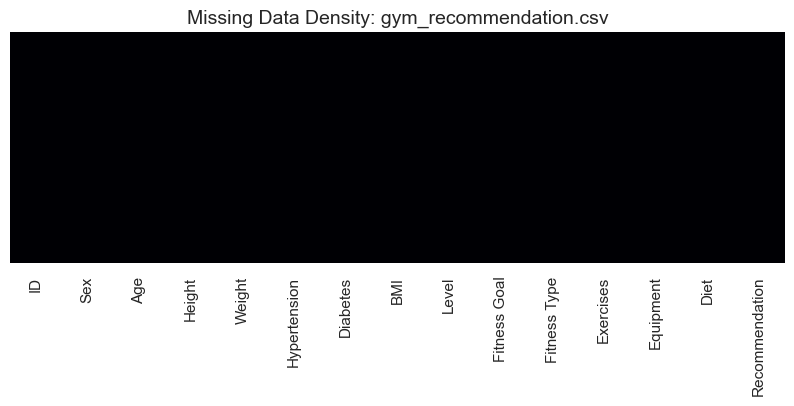

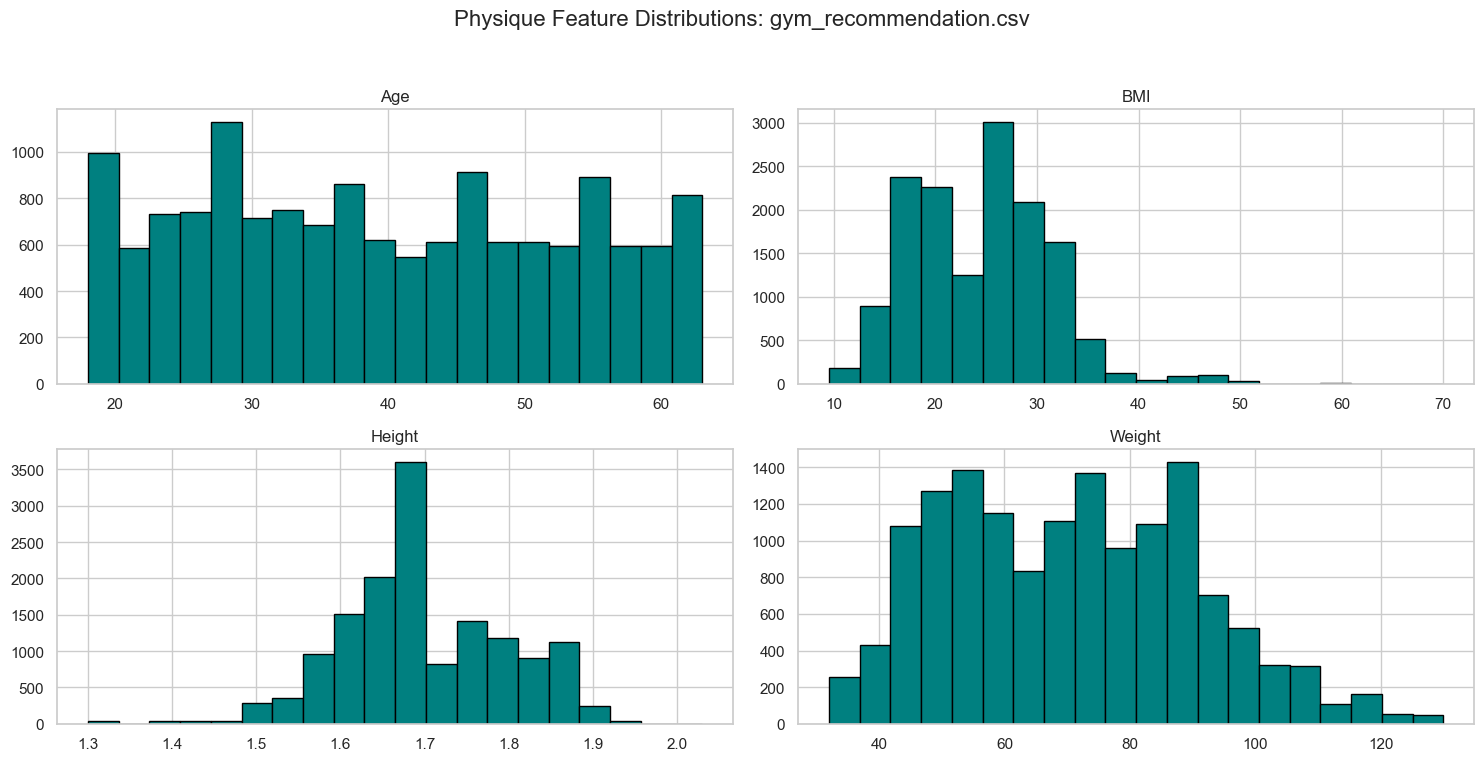

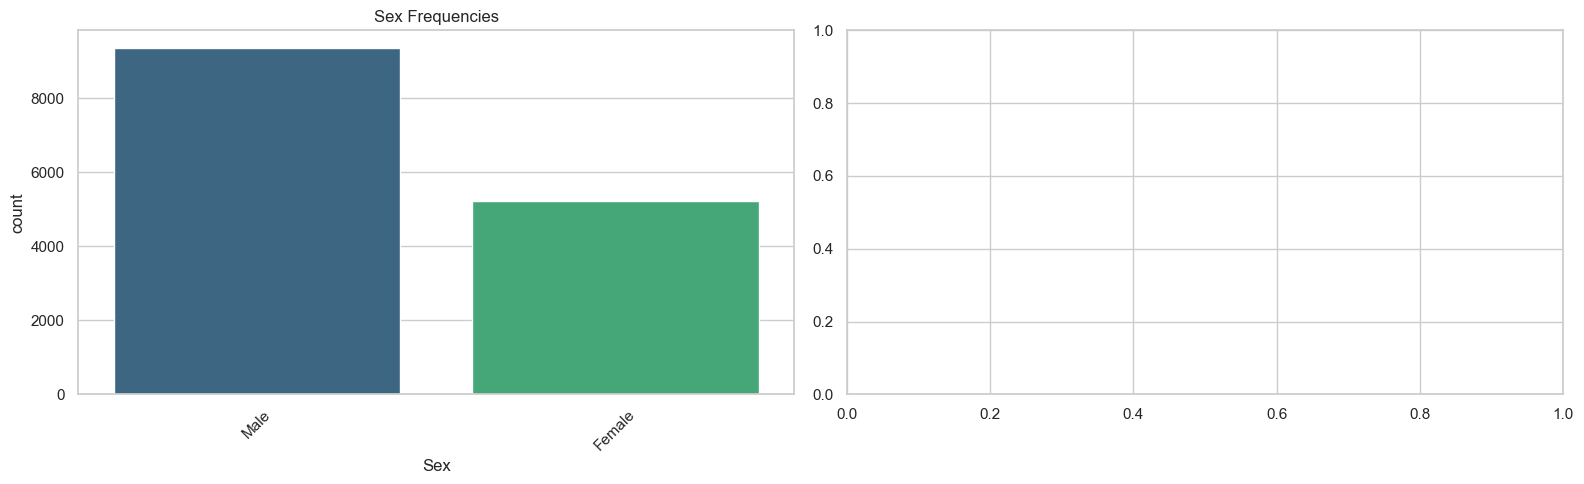

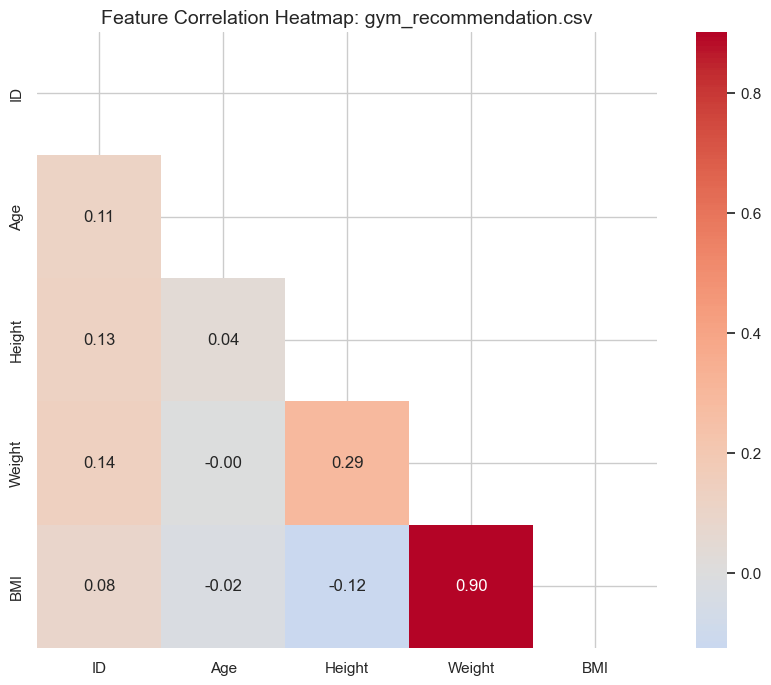


==================== ANALYZING: diet_recommendations.csv ====================
Shape: (1000, 20)


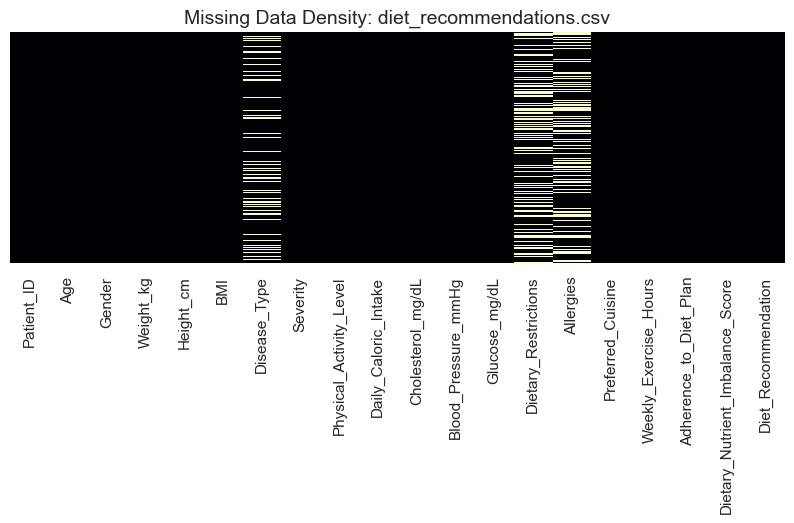

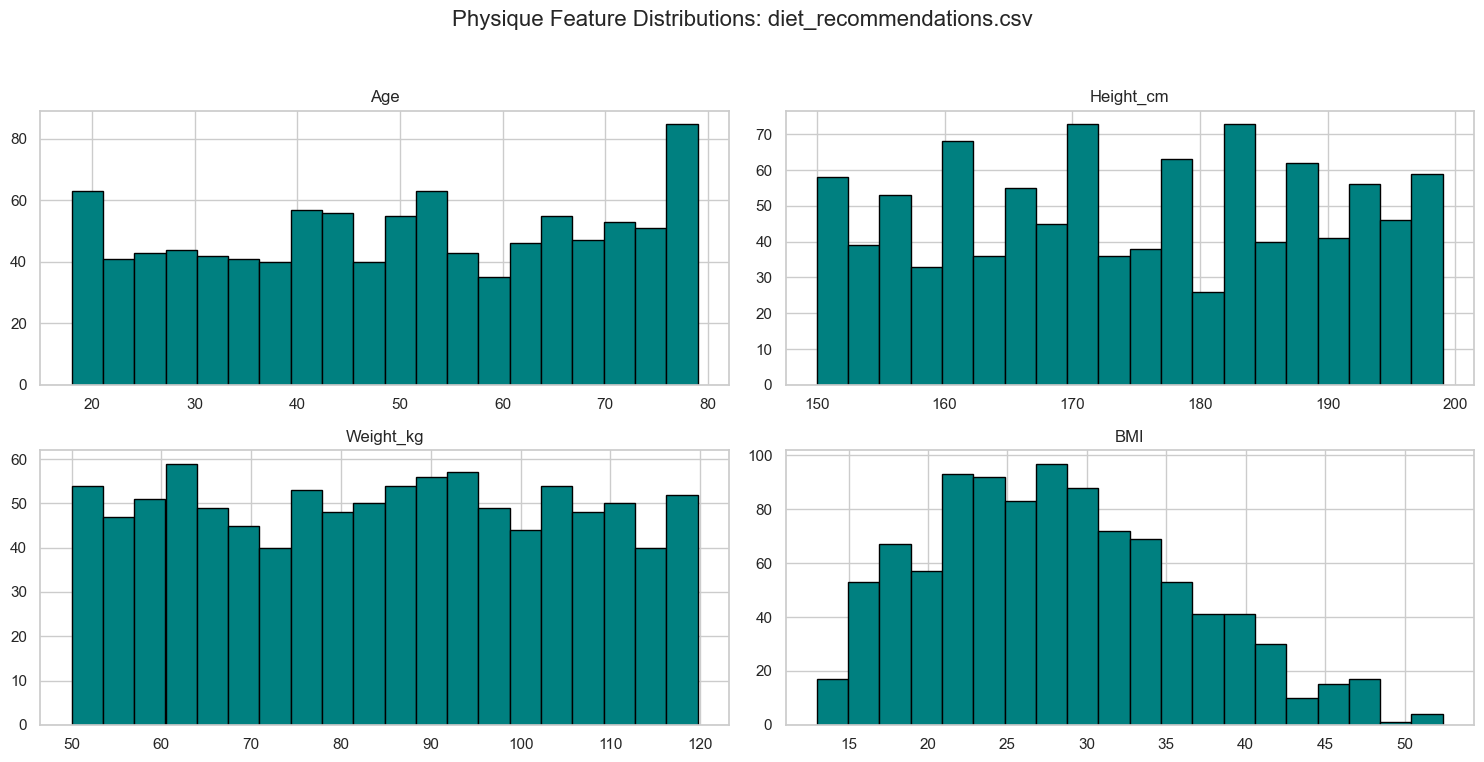

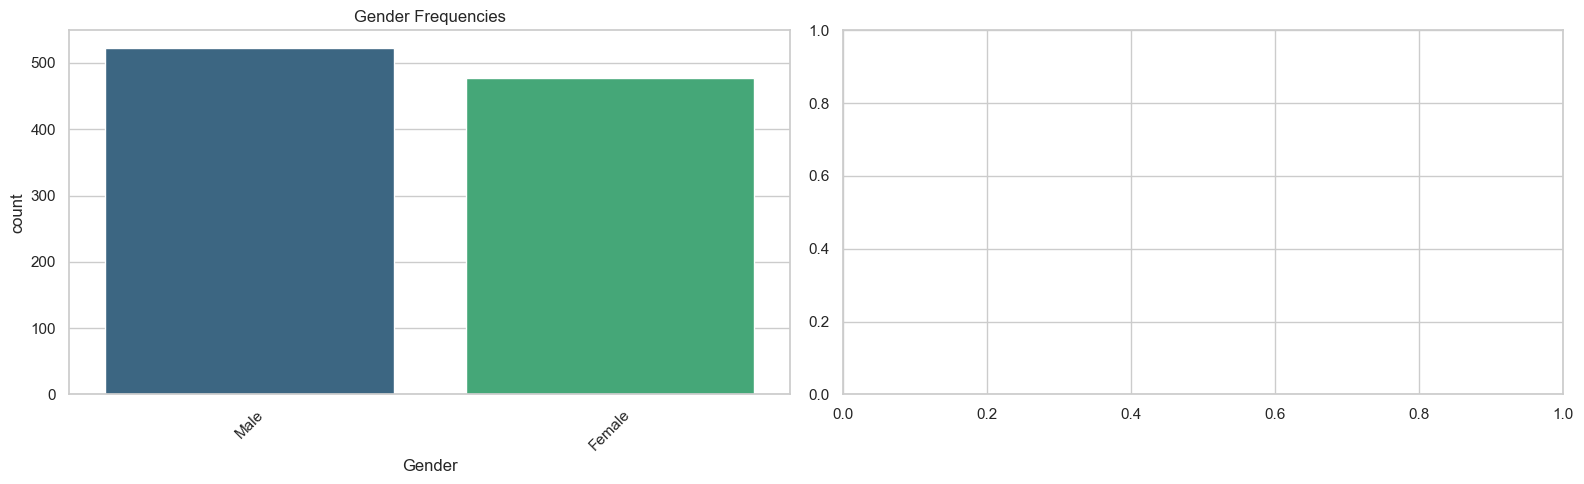

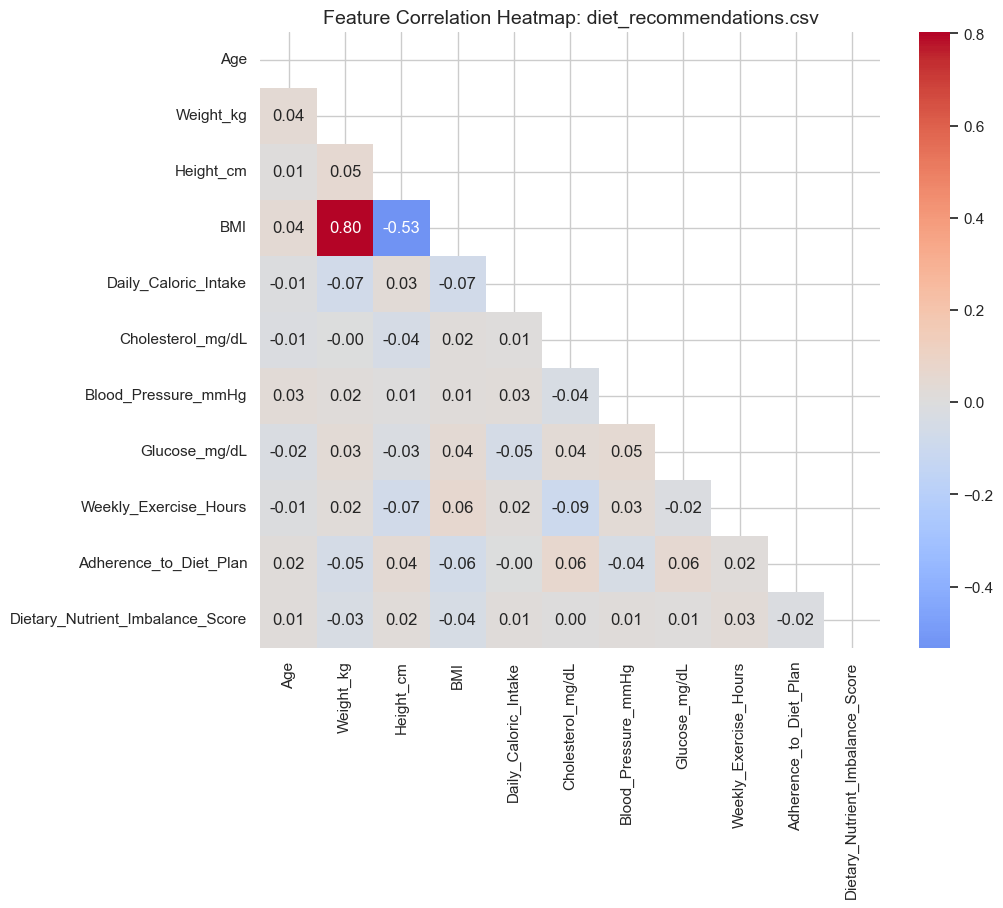


==================== ANALYZING: personalized_medical_diet.csv ====================
Shape: (5000, 30)


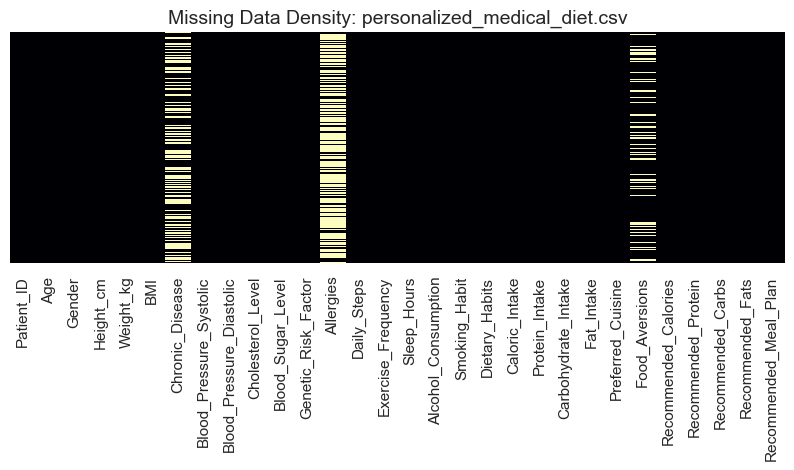

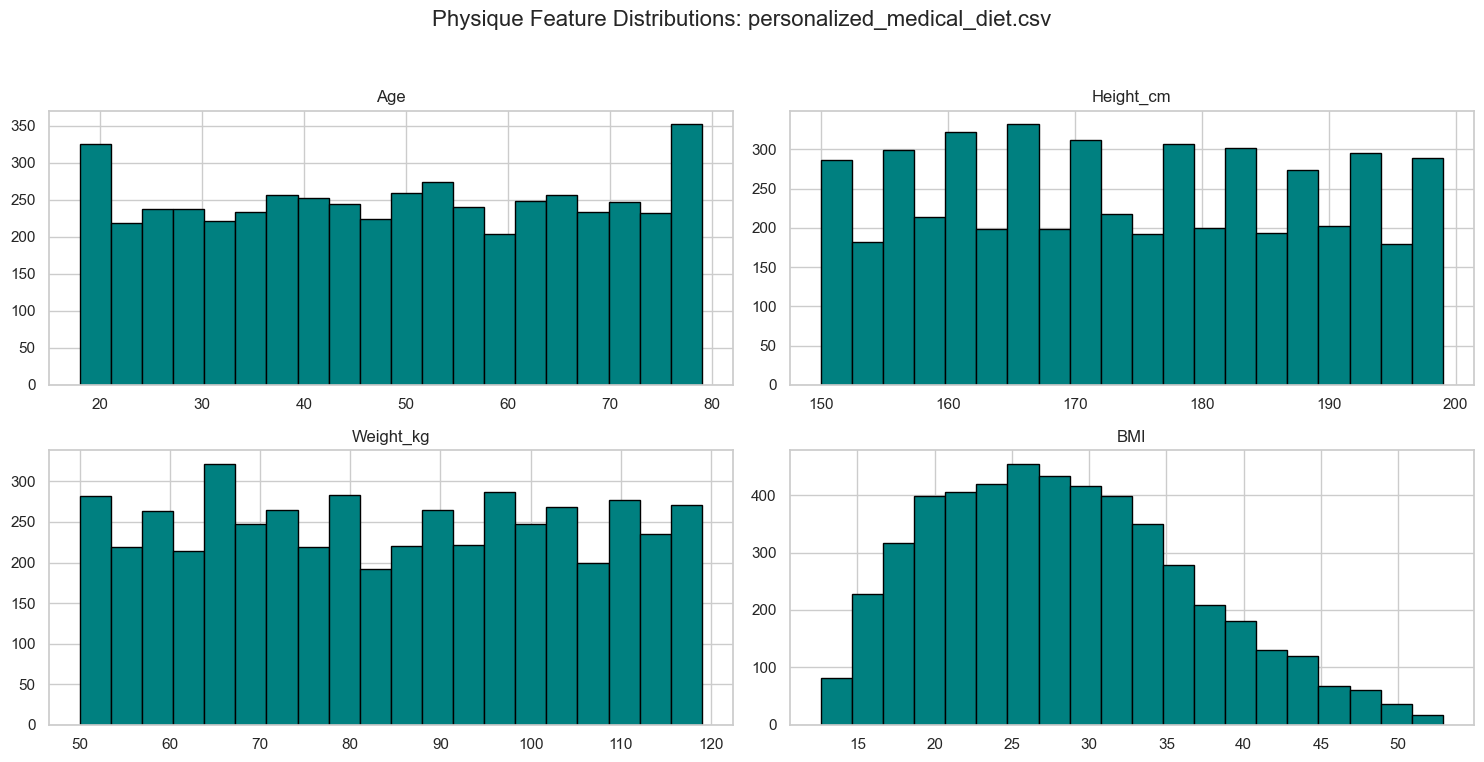

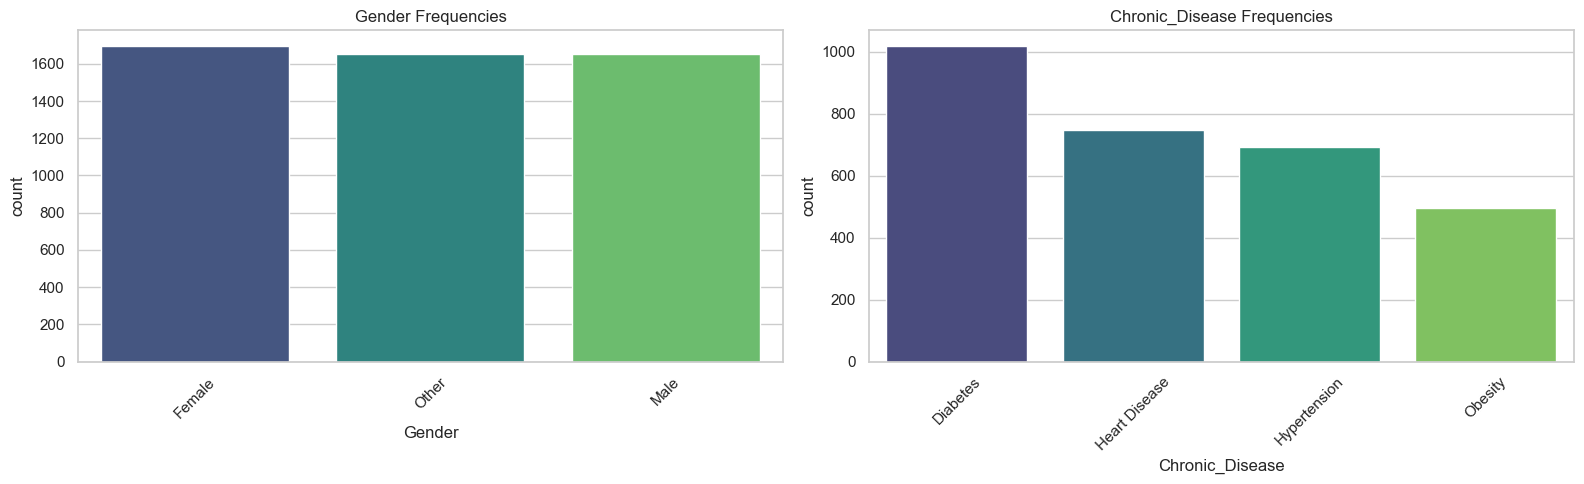

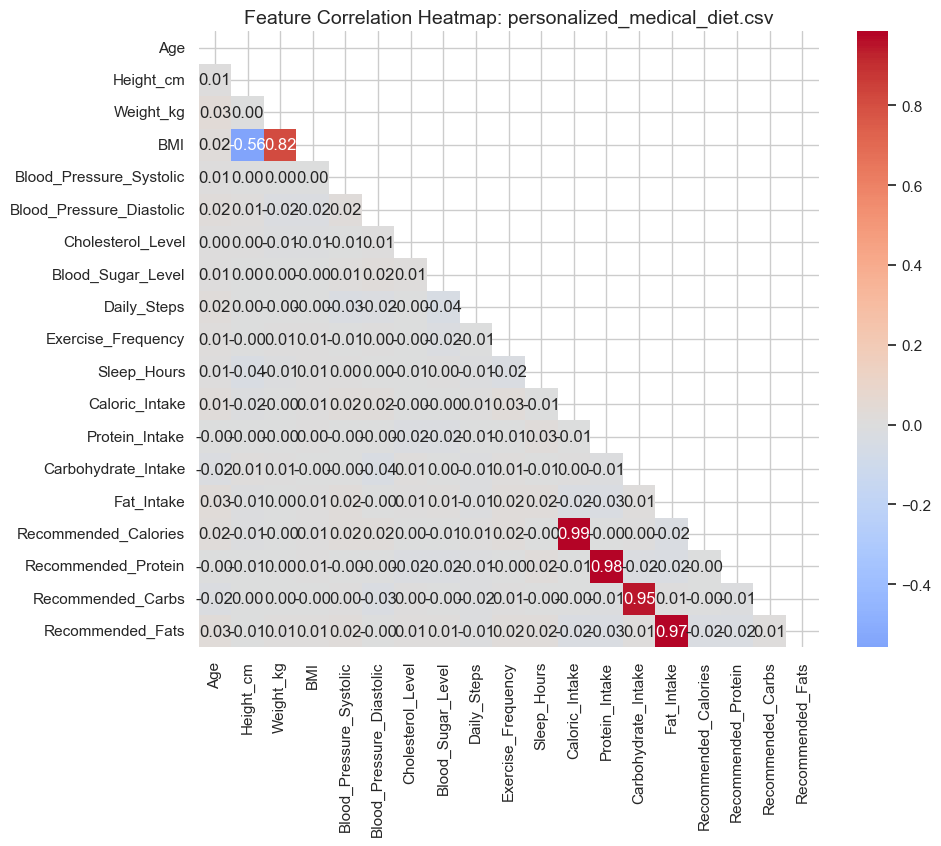


==================== ANALYZING: diet_workout_dataset.csv ====================
Shape: (2600, 5)


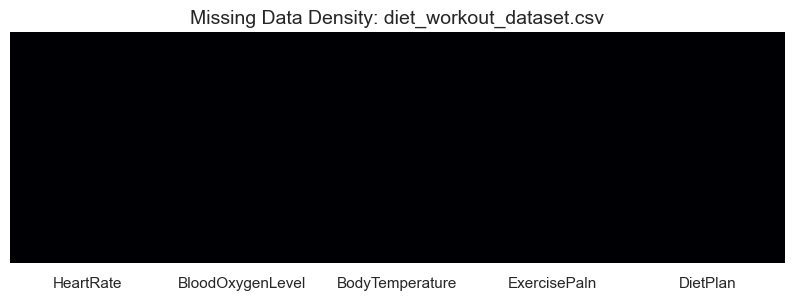

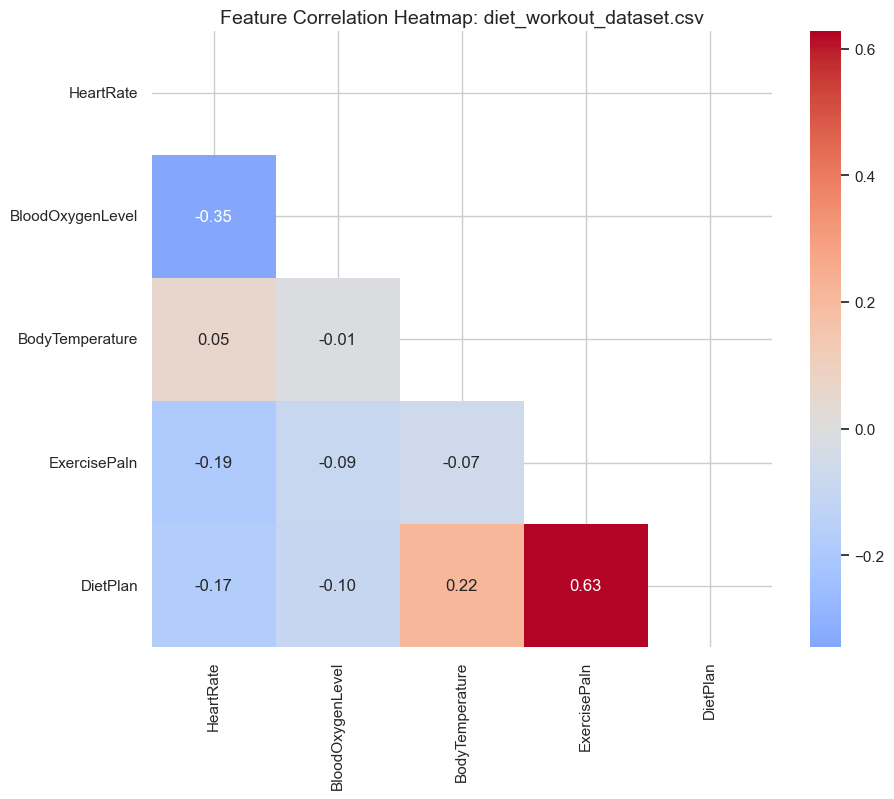

In [8]:
def plot_aesthetic_eda(df, name):
    print(f"\n{'='*20} ANALYZING: {name} {'='*20}")
    print(f"Shape: {df.shape}")
    
    # 1. Missing Data Matrix
    plt.figure(figsize=(10, 3))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')
    plt.title(f'Missing Data Density: {name}', fontsize=14)
    plt.show()
    
    # 2. Distributions of Physique Metrics
    physique_cols = [c for c in ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Height', 'Weight'] if c in df.columns]
    if physique_cols:
        df[physique_cols].hist(bins=20, figsize=(15, 8), color='teal', edgecolor='black')
        plt.suptitle(f'Physique Feature Distributions: {name}', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    
    # 3. Categorical Insights
    cat_cols = [c for c in ['Gender', 'Sex', 'Chronic_Disease', 'Fitness_Goal', 'Activity_Level'] if c in df.columns]
    if cat_cols:
        nrows = (len(cat_cols) + 1) // 2
        fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 5*nrows))
        axes = axes.flatten()
        for i, col in enumerate(cat_cols):
            sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='viridis')
            axes[i].set_title(f'{col} Frequencies', fontsize=12)
            axes[i].tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    # 4. Correlation Heatmap
    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr = num_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title(f'Feature Correlation Heatmap: {name}', fontsize=14)
        plt.show()

for path in sources:
    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        plot_aesthetic_eda(temp_df, os.path.basename(path))
    else:
        print(f"⚠️ Warning: {path} not found.")

## 2. Merged Dataset Analysis
Now we inspect the unified corpus after merging logic has been applied.


✓ Loaded merged dataset with 23189 rows.


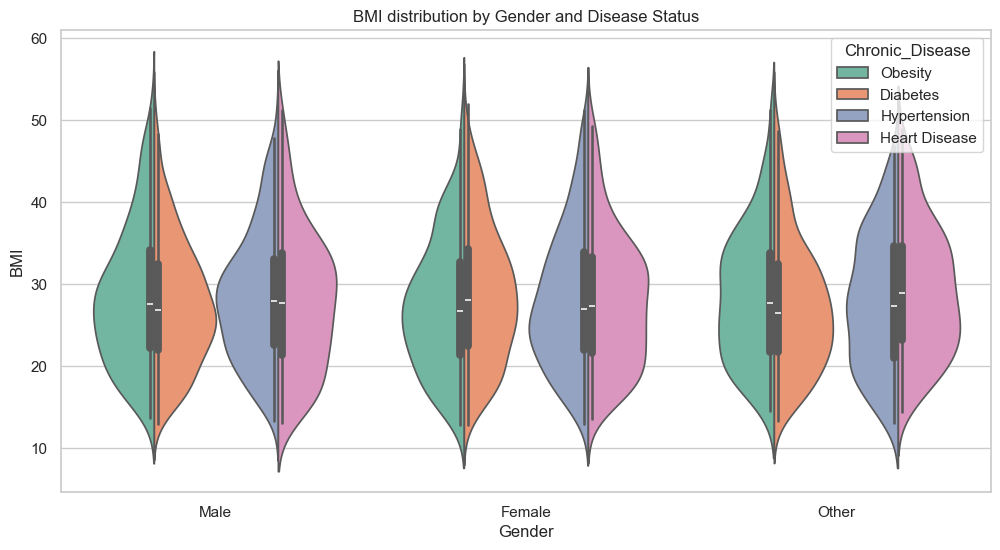

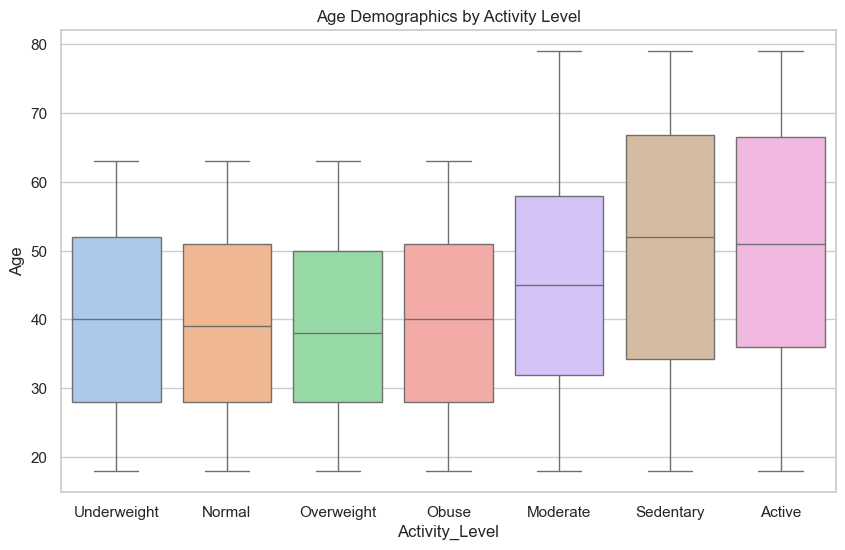

In [9]:
if os.path.exists(MERGED_PATH):
    df_merged = pd.read_csv(MERGED_PATH)
    print(f"✓ Loaded merged dataset with {df_merged.shape[0]} rows.")
    
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df_merged, x='Gender', y='BMI', hue='Chronic_Disease', split=True, palette='Set2')
    plt.title('BMI distribution by Gender and Disease Status')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_merged, x='Activity_Level', y='Age', palette='pastel')
    plt.title('Age Demographics by Activity Level')
    plt.show()
else:
    print(f"❌ Run merge_datasets.py to generate {MERGED_PATH}.")